This page is dedicated to investigate some characteristics appeared in the MSE versus $\hat{R}_{\nu}$ scatter plot. Mainly, there are two primary observations:
1. even the warmup length has increased to 1000 steps, some dimension would still have high $\hat{R}_{\nu}$ compare to other dimension.
2. there is a symmetry around the $\hat{R}_{\nu}-1$ threshold on the log scale.

**Environment Setup**

In [ ]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


**Necessary Parameter Setup**

In [ ]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [ ]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

**Function Setup**

In [ ]:
utility_link = '/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/Report_files/investigateUtil.py'
with open(utility_link) as f: exec(f.read())

**Rosenbrock Example**

In [ ]:
##########################
# TFP implementation:
##########################
# MSE vs Warmups:
tfp_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_MSE_constrained.pkl"
tfp_MSE_c_df = pd.read_pickle(tfp_MSE_c_path)

tfp_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_MSE_naive.pkl"
tfp_MSE_n_df = pd.read_pickle(tfp_MSE_n_path)
# MSE vs nested Rhat:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
print("TFP implementation data Loaded!")
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
bjx_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_MSE_constrained.pkl"
bjx_MSE_c_df = pd.read_pickle(bjx_MSE_c_path)

bjx_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_MSE_naive.pkl"
bjx_MSE_n_df = pd.read_pickle(bjx_MSE_n_path)
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")
##########################
# BlackJAX implementation, with PathFinder Initialization:
##########################
# MSE vs Warmups:
pf_MSE_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/Rosen_MSE.pkl"
pf_MSE_df = pd.read_pickle(pf_MSE_path)
# MSE vs nested Rhat:
pf_R_Hat_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/Rosen_R_Hat.pkl"
pf_R_Hat_df = pd.read_pickle(pf_R_Hat_path)
print("PathFinder implementation data Loaded!")

TFP implementation data Loaded!
BlackJAX implementation data Loaded!
PathFinder implementation data Loaded!


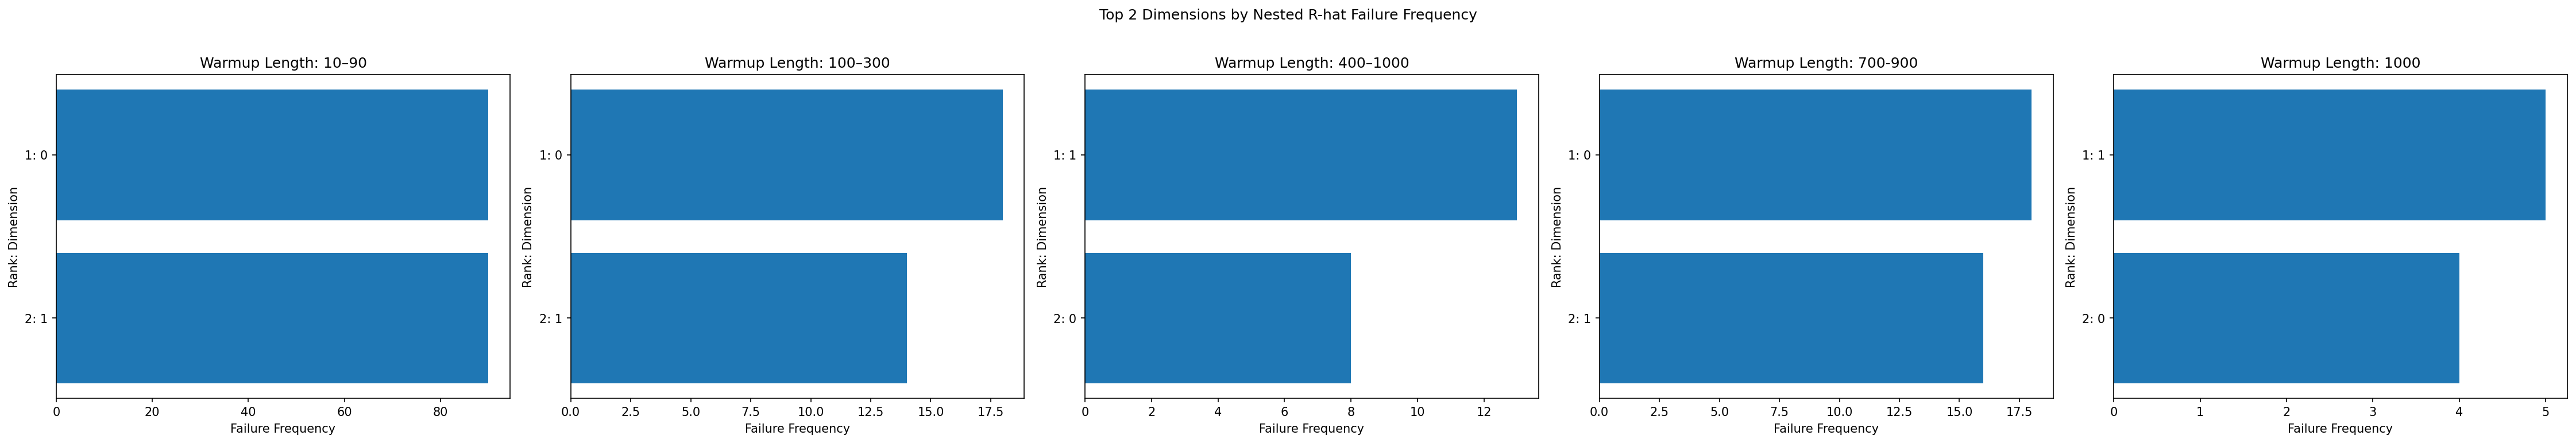

{'10–90': Dimension
 1    90
 0    90
 Name: Rhat Failure, dtype: int64,
 '100–300': Dimension
 1    14
 0    18
 Name: Rhat Failure, dtype: int64,
 '400–1000': Dimension
 0     8
 1    13
 Name: Rhat Failure, dtype: int64,
 '700-900': Dimension
 1    16
 0    18
 Name: Rhat Failure, dtype: int64,
 '1000': Dimension
 0    4
 1    5
 Name: Rhat Failure, dtype: int64}

In [ ]:
warmup_groups = {
            "10–90": (10, 90),
            "100–300": (100, 300),
            "400–1000": (400, 600),
            "700-900":(700,900),
            "1000":(1000,1000)
        }

plot_top_dimension_failures(
    tfp_R_Hat_c_df,
    bound,
    threshold,
    warmup_groups,
    top_n=2,
    figsize_per_subplot=(6, 5),
)

**Eight Schools Example**

In [ ]:
##########################
# TFP implementation:
##########################
# MSE vs Warmups:
tfp_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_MSE_constrained.pkl"
tfp_MSE_c_df = pd.read_pickle(tfp_MSE_c_path)

tfp_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_MSE_naive.pkl"
tfp_MSE_n_df = pd.read_pickle(tfp_MSE_n_path)
# MSE vs nested Rhat:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
print("TFP implementation data Loaded!")
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
bjx_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_MSE_constrained.pkl"
bjx_MSE_c_df = pd.read_pickle(bjx_MSE_c_path)

bjx_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_MSE_naive.pkl"
bjx_MSE_n_df = pd.read_pickle(bjx_MSE_n_path)
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")
##########################
# BlackJAX implementation, with PathFinder Initialization:
##########################
# MSE vs Warmups:
pf_MSE_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/School_MSE.pkl"
pf_MSE_df = pd.read_pickle(pf_MSE_path)
# MSE vs nested Rhat:
pf_R_Hat_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/School_R_Hat.pkl"
pf_R_Hat_df = pd.read_pickle(pf_R_Hat_path)
print("PathFinder implementation data Loaded!")

TFP implementation data Loaded!
BlackJAX implementation data Loaded!
PathFinder implementation data Loaded!


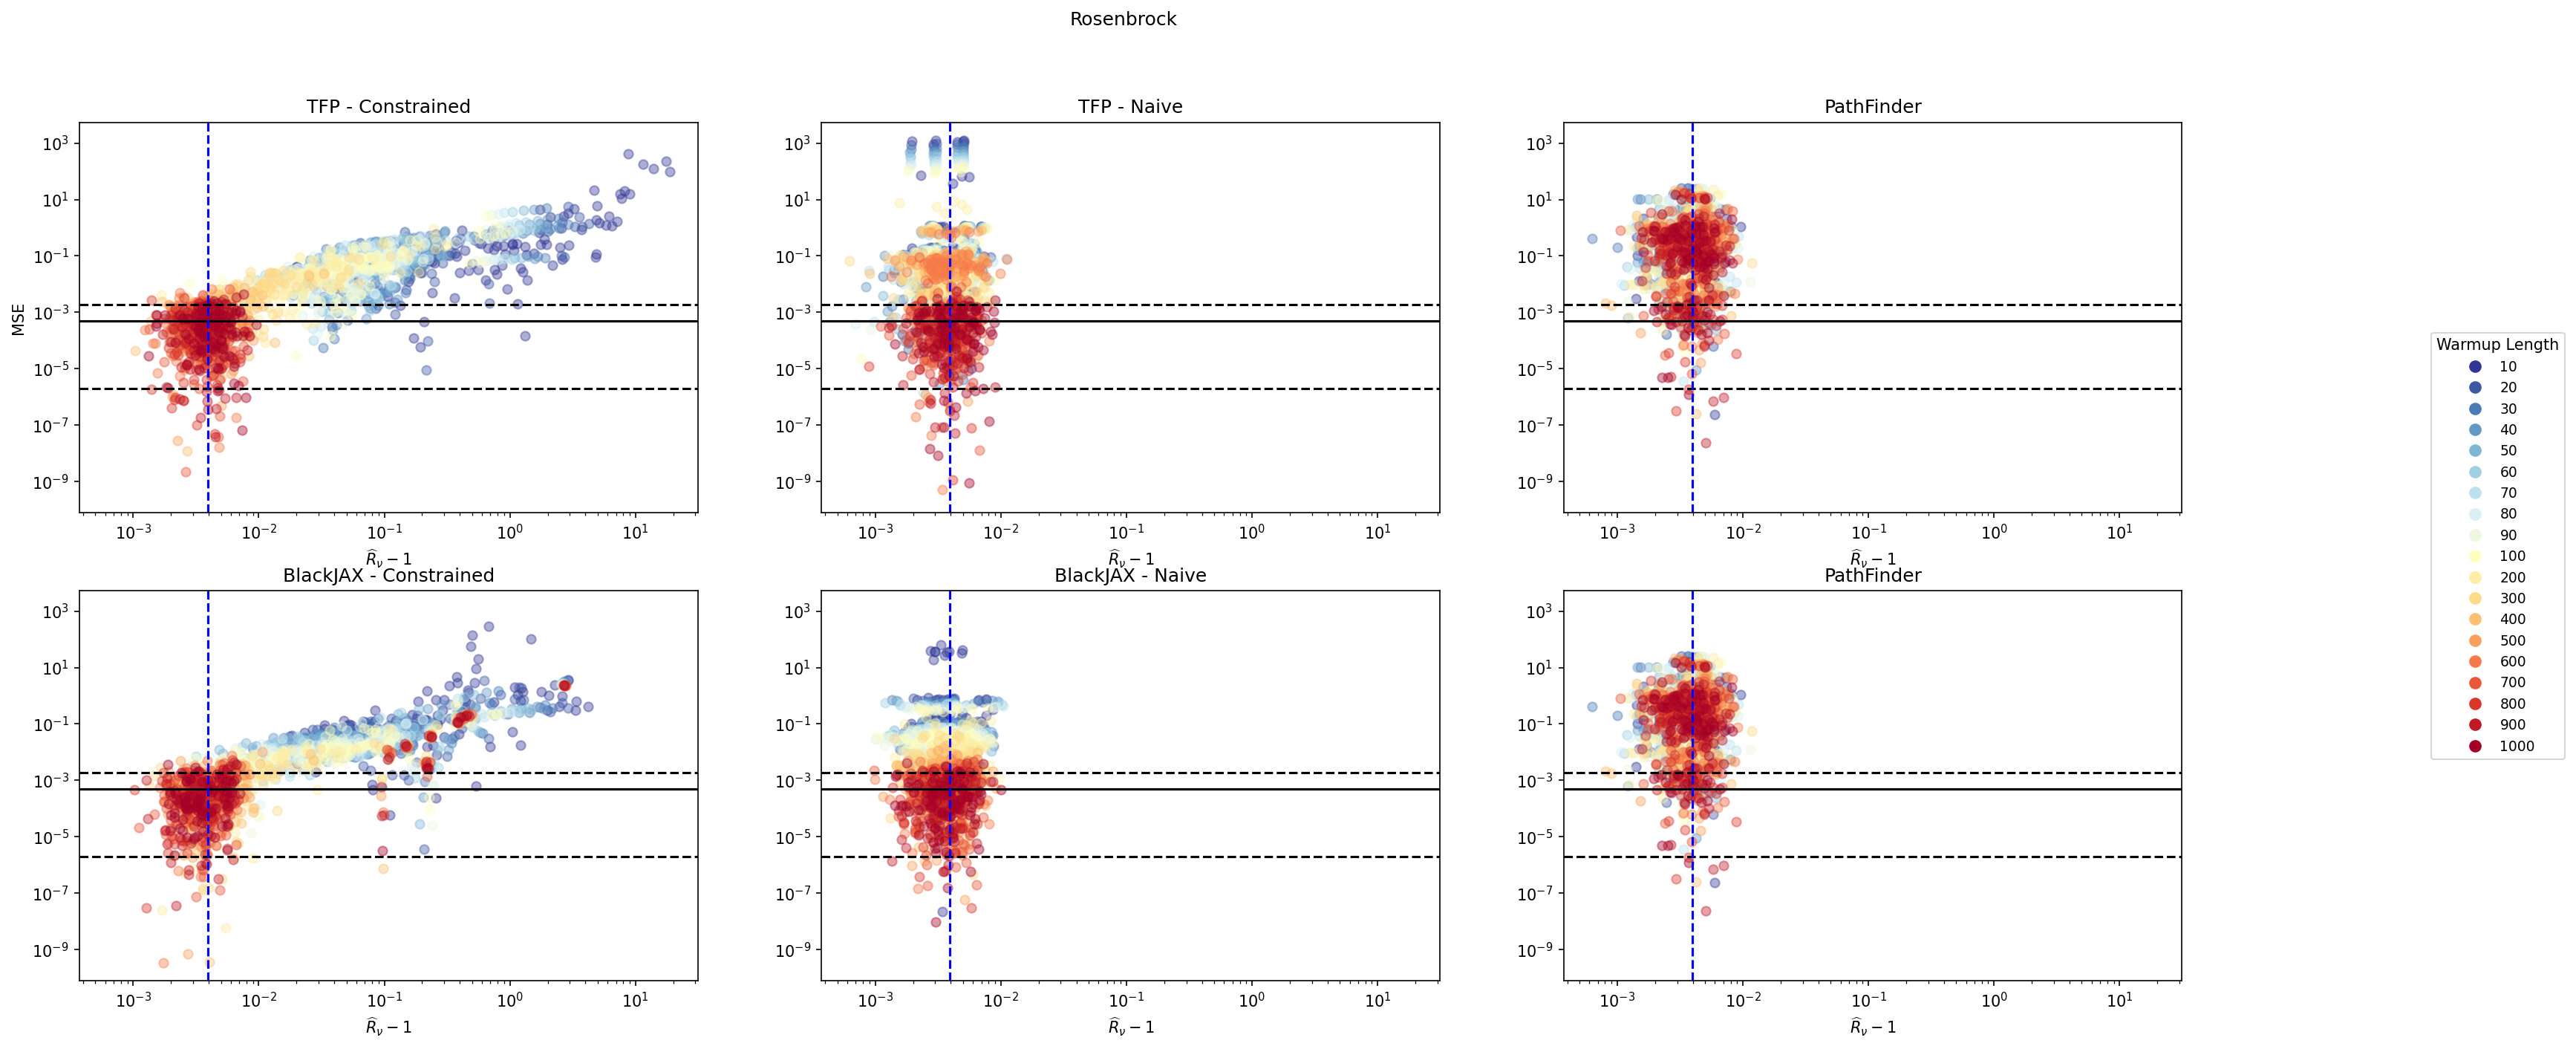

In [ ]:
MSE_vs_Rhat_color(tfp_R_Hat_c_df, tfp_R_Hat_n_df, bjx_R_Hat_c_df, bjx_R_Hat_n_df,pf_R_Hat_df,
                  "Rosenbrock",bound, threshold,num_chains_short,"Warmup Length")

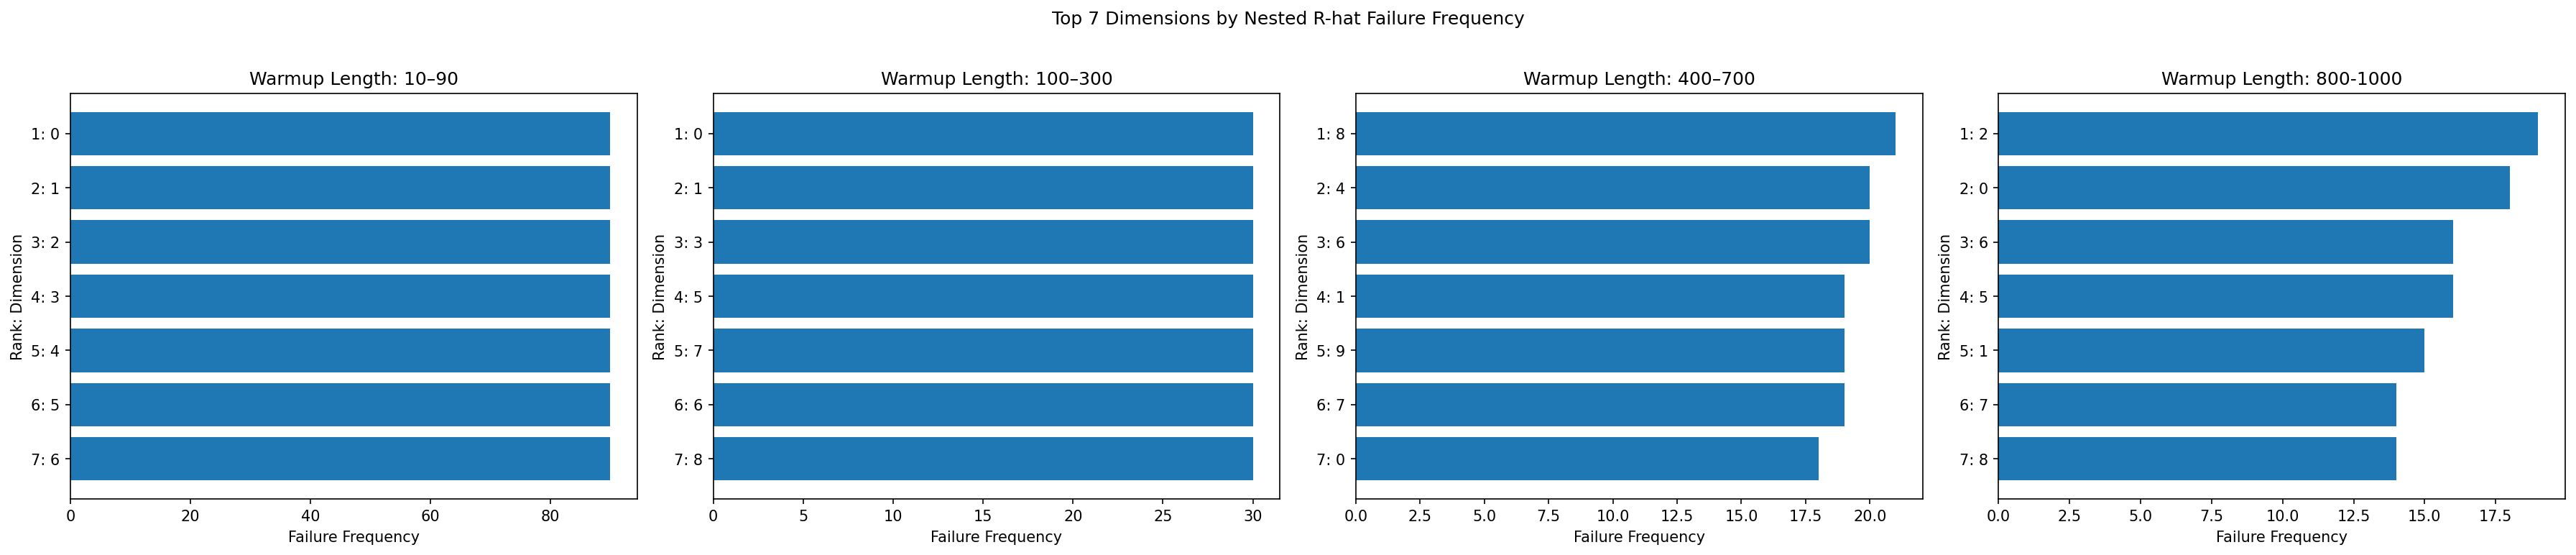

{'10–90': Dimension
 6    90
 5    90
 4    90
 3    90
 2    90
 1    90
 0    90
 Name: Rhat Failure, dtype: int64,
 '100–300': Dimension
 8    30
 6    30
 7    30
 5    30
 3    30
 1    30
 0    30
 Name: Rhat Failure, dtype: int64,
 '400–700': Dimension
 0    18
 7    19
 9    19
 1    19
 6    20
 4    20
 8    21
 Name: Rhat Failure, dtype: int64,
 '800-1000': Dimension
 8    14
 7    14
 1    15
 5    16
 6    16
 0    18
 2    19
 Name: Rhat Failure, dtype: int64}

In [ ]:
warmup_groups = {
            "10–90": (10, 90),
            "100–300": (100, 300),
            "400–700": (400, 700),
            "800-1000":(800,1000)
        }

plot_top_dimension_failures(
    tfp_R_Hat_c_df,
    bound,
    threshold,
    warmup_groups,
    top_n=7,
    figsize_per_subplot=(6, 5),
)

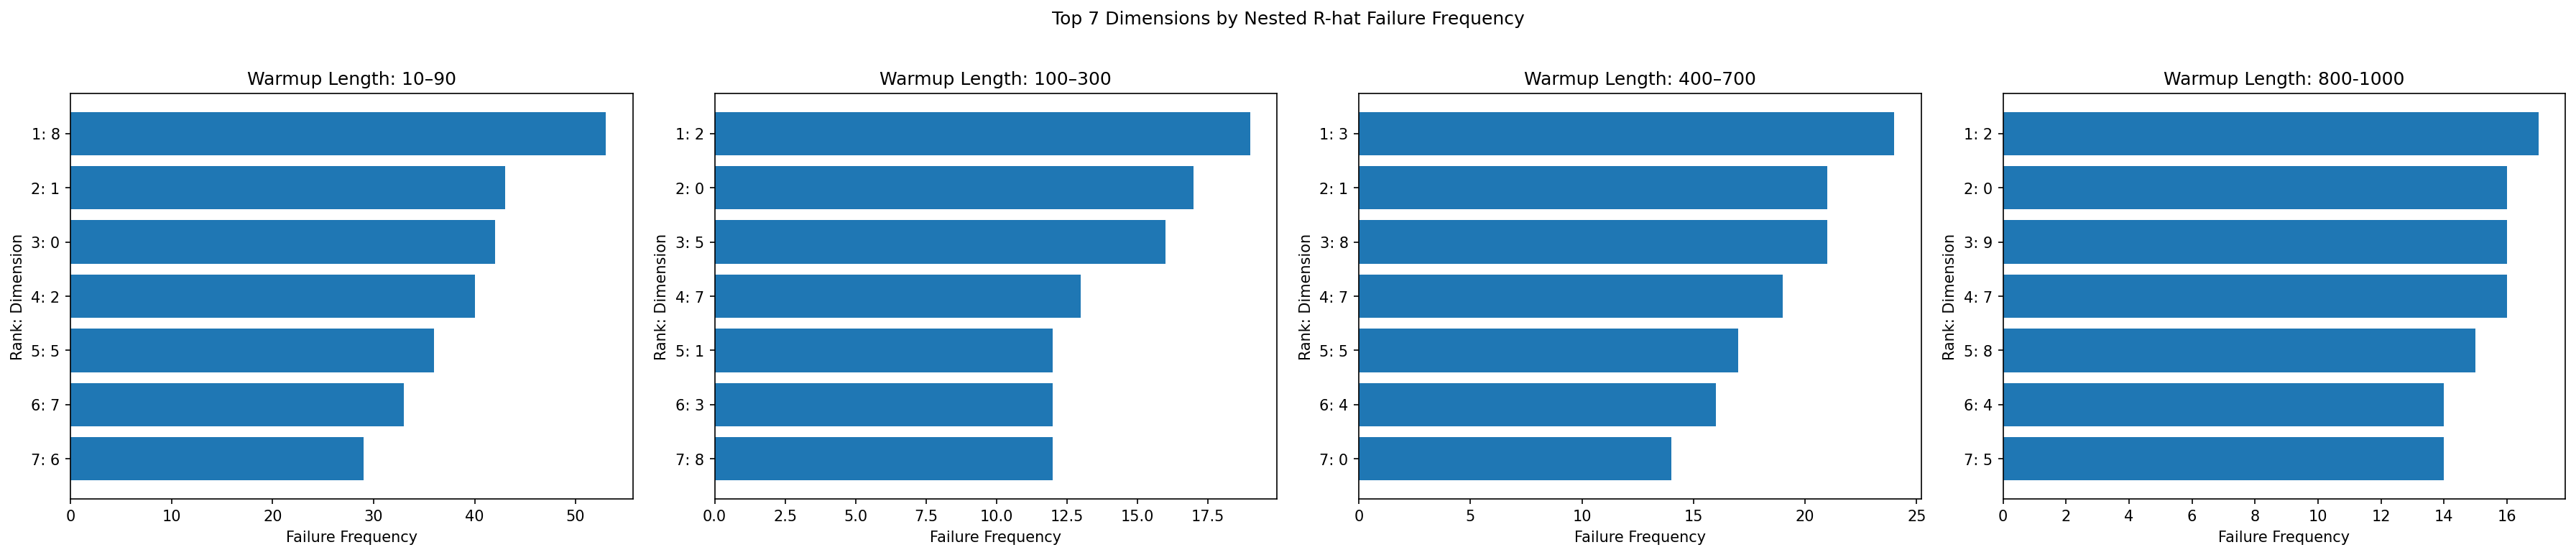

{'10–90': Dimension
 6    29
 7    33
 5    36
 2    40
 0    42
 1    43
 8    53
 Name: Rhat Failure, dtype: int64,
 '100–300': Dimension
 8    12
 3    12
 1    12
 7    13
 5    16
 0    17
 2    19
 Name: Rhat Failure, dtype: int64,
 '400–700': Dimension
 0    14
 4    16
 5    17
 7    19
 8    21
 1    21
 3    24
 Name: Rhat Failure, dtype: int64,
 '800-1000': Dimension
 5    14
 4    14
 8    15
 7    16
 9    16
 0    16
 2    17
 Name: Rhat Failure, dtype: int64}

In [ ]:
warmup_groups = {
            "10–90": (10, 90),
            "100–300": (100, 300),
            "400–700": (400, 700),
            "800-1000":(800,1000)
        }

plot_top_dimension_failures(
    tfp_R_Hat_n_df,
    bound,
    threshold,
    warmup_groups,
    top_n=7,
    figsize_per_subplot=(6, 5),
)

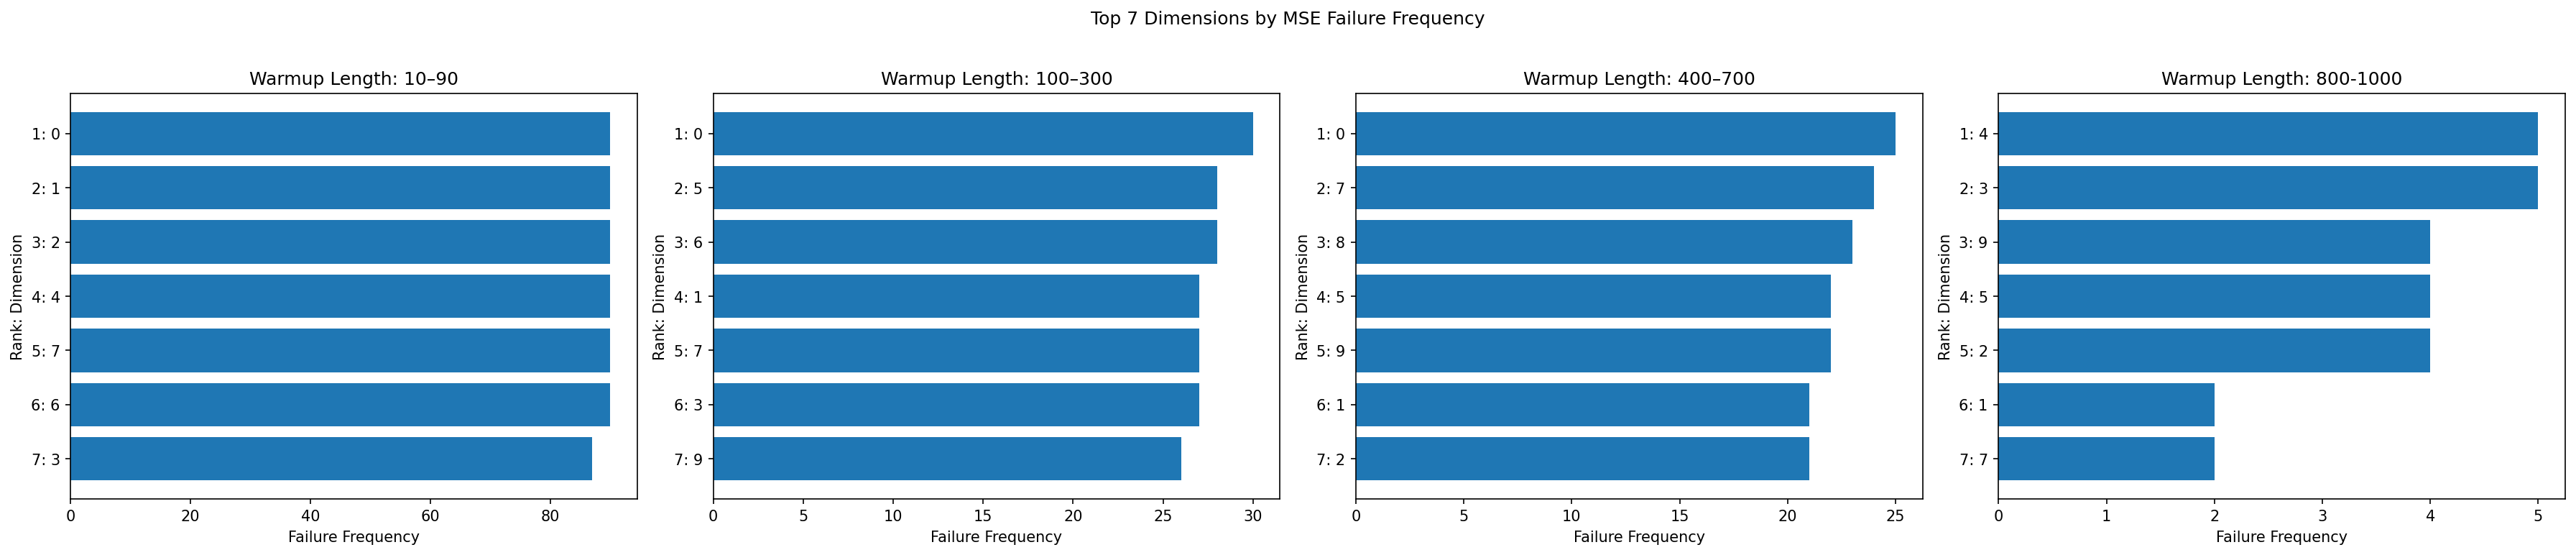

{'10–90': Dimension
 3    87
 6    90
 7    90
 4    90
 2    90
 1    90
 0    90
 Name: MSE Failure, dtype: int64,
 '100–300': Dimension
 9    26
 3    27
 7    27
 1    27
 6    28
 5    28
 0    30
 Name: MSE Failure, dtype: int64,
 '400–700': Dimension
 2    21
 1    21
 9    22
 5    22
 8    23
 7    24
 0    25
 Name: MSE Failure, dtype: int64,
 '800-1000': Dimension
 7    2
 1    2
 2    4
 5    4
 9    4
 3    5
 4    5
 Name: MSE Failure, dtype: int64}

In [ ]:
plot_top_dimension_failures(
    tfp_R_Hat_n_df,
    bound,
    threshold,
    warmup_groups,
    top_n=7,
    figsize_per_subplot=(6, 5),
    criterion="MSE"
)